In [1]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

[9683. 9088. 1488.  271.  110.] [ 0.4999   3.39994  6.29998  9.20002 12.10006 15.0001 ]


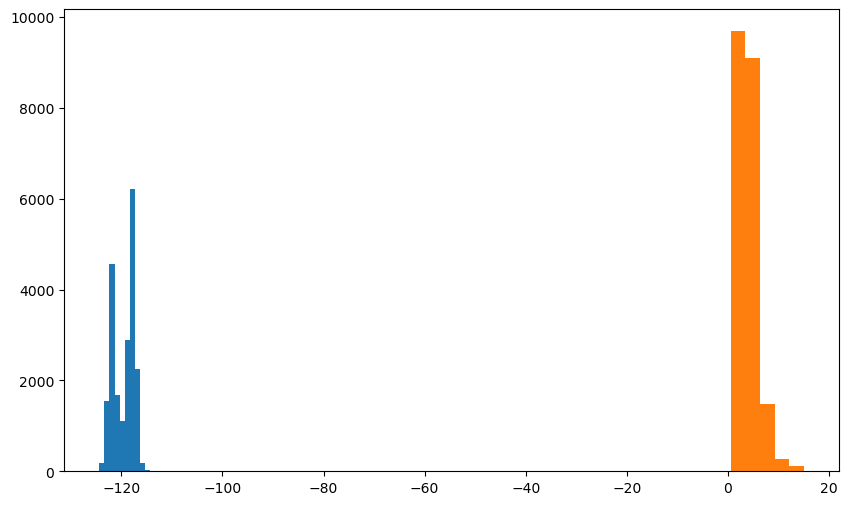

In [2]:
import matplotlib.pyplot as plt

fig,ax=plt.subplots(figsize=(10,6))
ax.hist(housing['longitude'])

hists = plt.hist(housing['median_income'],bins=5)
print(hists[0],hists[1])
housing['income_cat'] =  pd.cut(housing['median_income'],bins=hists[1], labels=[1,2,3,4,5])
plt.show()

In [ ]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(10,6))
sns.countplot(data=housing,x='income_cat',ax=ax,palette='rainbow',hue='income_cat')
plt.show()

In [ ]:
sample = housing.dropna()
sample['income_cat'] = sample.loc[:,'income_cat'].astype(int)

In [ ]:
from sklearn.model_selection import  train_test_split
train,test = train_test_split(sample,test_size=0.2,random_state=42,
                              stratify=sample['income_cat']
                              )
fig, axes = plt.subplots(1,2,figsize=(12,6))
axes[0].set_title('train')
axes[1].set_title('test')
sns.countplot(data=train, x='income_cat',hue='income_cat',ax=axes[0])
sns.countplot(data=test, x='income_cat',hue='income_cat',ax=axes[1])
plt.tight_layout()
plt.show()

In [ ]:
housing

In [3]:
# 데이터 분할
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# 단순히 훈련용 세트와 테스트용 세트로 쪼개기만 할 때 사용.
train_set , test_set = train_test_split(housing, test_size=0.2 , random_state=42)

# 훈련용 데이터 x와 y를 분리

housing_train = train_set.drop('median_house_value' , axis=1)
housing_labels = train_set['median_house_value'].copy()

num_attribs = list(housing_train.select_dtypes(np.number))
cat_attribs = ['ocean_proximity']

num_pipeline = Pipeline(steps=[
    ('imputer' , SimpleImputer(strategy='median')) , ('scaler' , StandardScaler())
])

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessing = ColumnTransformer([
    ('num' , num_pipeline , num_attribs) ,
    ('cat' , OneHotEncoder() , cat_attribs)
])

from sklearn.linear_model import LinearRegression
pipeline = Pipeline([
    ('preprocess' , preprocessing) , ('model' , LinearRegression())
])

pipeline.fit(housing_train , housing_labels)
housing_test = test_set.drop('median_house_value' , axis=1)
housing_test_labels = test_set['median_house_value'].copy()
pipeline.score(housing_test , housing_test_labels)

0.6486352079787185

In [4]:
# 의사결정나무
# - CART 알고리즘
from sklearn.tree import DecisionTreeRegressor
tree_pipeline = Pipeline([
    ('preprocess' , preprocessing) , ('model' , DecisionTreeRegressor())
])
tree_pipeline.fit(housing_train , housing_labels)
tree_pipeline.score(housing_test,housing_test_labels)

0.6659464797654734

In [5]:
from sklearn.ensemble import RandomForestRegressor
random_pipeline = Pipeline([
    ('preprocess' , preprocessing) , ('model' , RandomForestRegressor())
])
random_pipeline.fit(housing_train , housing_labels)
random_pipeline.score(housing_test , housing_test_labels)

0.8222014869340277

In [ ]:
import random
random_5 = random.sample(range(len(housing)) , 5)
housing.iloc[random_5]
print(random_5)
print(random_pipeline.predict(housing.iloc[random_5].drop('median_house_value' , axis=1)))
print(housing.iloc[random_5]['median_house_value'].values)

In [7]:
# 튜닝 - 모델
param_grid = [
    {'model__n_estimators':[30,100,200], 'model__max_features':[2,4,6]}
]
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(random_pipeline, param_grid=param_grid,cv=3)
grid_search.fit(housing.drop('median_house_value', axis=1), housing['median_house_value'])

,estimator,Pipeline(step...Regressor())])
,param_grid,"[{'model__max_features': [2, 4, ...], 'model__n_estimators': [30, 100, ...]}]"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"
